## Objetivo: estimar el precio de las viviendas de Boston

## Importamos las librerias

In [1]:
#Procesamiento de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Importamos las librerias para machine learning

from sklearn.datasets import load_boston
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid
from sklearn.inspection import permutation_importance
import multiprocessing

In [3]:
import warnings
warnings.filterwarnings('once')

In [4]:
boston = load_boston(return_X_y=False)
#Apila una columna en la otra
datos = np.column_stack((boston.data, boston.target))
datos = pd.DataFrame(datos,columns = np.append(boston.feature_names, "MEDV"))
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


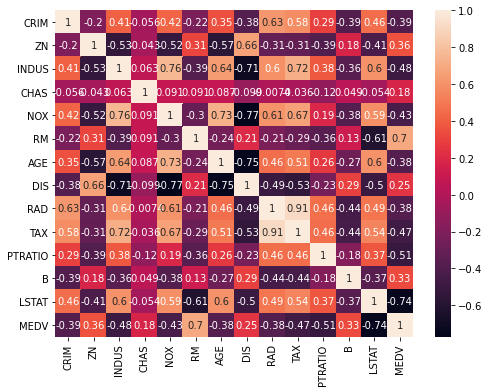

In [5]:
#Evaluamos colinearidad

matriz =datos.corr(method='pearson')
matriz

plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True)
plt.show()


In [20]:
#Dividimos el dataset en train y test

X_train, X_test, y_train, y_test = train_test_split(
                                        datos.drop(columns = "MEDV"),
                                        datos['MEDV'],
                                        random_state = 123
                                    )
X_train.head()

len(X_train)


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
335,0.03961,0.0,5.19,0.0,0.515,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01
142,3.32105,0.0,19.58,1.0,0.871,5.403,100.0,1.3216,5.0,403.0,14.7,396.90,26.82
170,1.20742,0.0,19.58,0.0,0.605,5.875,94.6,2.4259,5.0,403.0,14.7,292.29,14.43
241,0.10612,30.0,4.93,0.0,0.428,6.095,65.1,6.3361,6.0,300.0,16.6,394.62,12.40
379,17.86670,0.0,18.10,0.0,0.671,6.223,100.0,1.3861,24.0,666.0,20.2,393.74,21.78


In [7]:
#Creamos el modelo

modeloRF = RandomForestRegressor(
            n_estimators = 10,
            criterion    = 'mse',
            max_depth    = None,
            max_features = 'auto',
            oob_score    = False,
            n_jobs       = -1,
            random_state = 123
         )
#Ajustamos el modelo

modeloRF.fit(X_train,y_train)


RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=123)

In [8]:
#Realizamos las primeras predicciones sin tuning

predicciones = modeloRF.predict(X_test)



C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [9]:
rmse = mean_squared_error(y_test, predicciones, squared=False)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [10]:
print("El rmse del modelo sin tuning es",rmse.round(2))



El rmse del modelo sin tuning es 4.36


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


# Optimizacion de los hiperparámetros

## 2 Estrategia OOB error y cross validation con grid

In [11]:
param_grid = {'n_estimators': [150],
              'max_features': [5, 7, 9],
              'max_depth'   : [None, 3, 10, 20]
             }



In [12]:
grid = GridSearchCV(
        estimator  = RandomForestRegressor(random_state = 123),
        param_grid = param_grid,
        scoring    = 'neg_root_mean_squared_error',
        n_jobs     = multiprocessing.cpu_count() - 1,
        cv         = RepeatedKFold(n_splits=5, n_repeats=3, random_state=123), 
        refit      = True,
        verbose    = 0,
        return_train_score = True
       )

grid.fit(X = X_train, y = y_train)

GridSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=5, random_state=123),
             estimator=RandomForestRegressor(random_state=123), n_jobs=3,
             param_grid={'max_depth': [None, 3, 10, 20],
                         'max_features': [5, 7, 9], 'n_estimators': [150]},
             return_train_score=True, scoring='neg_root_mean_squared_error')

In [13]:
resultados = pd.DataFrame(grid.cv_results_)
resultados

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,...,split7_train_score,split8_train_score,split9_train_score,split10_train_score,split11_train_score,split12_train_score,split13_train_score,split14_train_score,mean_train_score,std_train_score
0,0.442483,0.053623,0.019655,0.007865,None,5,150,"{'max_depth': None, 'max_features': 5, 'n_esti...",-3.478109,-2.618231,...,-1.315490,-1.279117,-1.251651,-1.241555,-1.286718,-1.241003,-1.121094,-1.244844,-1.262209,0.070334
1,0.491778,0.039917,0.019646,0.007911,None,7,150,"{'max_depth': None, 'max_features': 7, 'n_esti...",-3.515318,-2.509807,...,-1.370337,-1.283300,-1.232495,-1.280241,-1.325750,-1.266365,-1.141663,-1.274498,-1.269434,0.064768
2,0.497958,0.055379,0.019554,0.009020,None,9,150,"{'max_depth': None, 'max_features': 9, 'n_esti...",-3.569180,-2.535386,...,-1.320031,-1.280262,-1.262440,-1.297634,-1.342024,-1.245558,-1.136220,-1.305288,-1.279376,0.070338
3,0.353585,0.040626,0.017710,0.006055,3,5,150,"{'max_depth': 3, 'max_features': 5, 'n_estimat...",-4.256364,-3.555995,...,-3.500761,-3.352000,-3.435725,-3.463552,-3.389566,-3.385054,-3.097665,-3.464722,-3.384473,0.129813
4,0.400714,0.024268,0.019699,0.005048,3,7,150,"{'max_depth': 3, 'max_features': 7, 'n_estimat...",-4.214979,-3.180300,...,-3.300172,-3.165008,-3.292946,-3.243883,-3.258944,-3.175749,-2.979295,-3.270921,-3.200298,0.113365
5,0.451010,0.031248,0.024976,0.008481,3,9,150,"{'max_depth': 3, 'max_features': 9, 'n_estimat...",-4.188696,-3.129073,...,-3.243605,-3.112549,-3.207883,-3.192096,-3.184597,-3.119927,-2.950190,-3.194833,-3.134360,0.105336
6,0.474457,0.067623,0.020229,0.008217,10,5,150,"{'max_depth': 10, 'max_features': 5, 'n_estima...",-3.465559,-2.635142,...,-1.429926,-1.334328,-1.315218,-1.330365,-1.401378,-1.301223,-1.188978,-1.317260,-1.332379,0.065084
7,0.464562,0.057634,0.020012,0.018423,10,7,150,"{'max_depth': 10, 'max_features': 7, 'n_estima...",-3.535546,-2.468216,...,-1.403090,-1.347164,-1.306652,-1.333189,-1.396988,-1.301245,-1.180939,-1.341186,-1.329324,0.066658
8,0.454075,0.034239,0.022090,0.007258,10,9,150,"{'max_depth': 10, 'max_features': 9, 'n_estima...",-3.591874,-2.537689,...,-1.390505,-1.325087,-1.323619,-1.333697,-1.395943,-1.272396,-1.192311,-1.362630,-1.329594,0.068472
9,0.394041,0.025550,0.020131,0.011178,20,5,150,"{'max_depth': 20, 'max_features': 5, 'n_estima...",-3.478544,-2.615940,...,-1.318200,-1.286102,-1.251094,-1.240702,-1.290746,-1.241003,-1.120536,-1.246117,-1.262743,0.070427


In [14]:
# Mejores hiperparámetros por validación cruzada
# ==============================================================================
print("----------------------------------------")
print("Mejores hiperparámetros encontrados (cv)")
print("----------------------------------------")
print(grid.best_params_, ":", grid.best_score_, grid.scoring)




----------------------------------------
Mejores hiperparámetros encontrados (cv)
----------------------------------------
{'max_depth': None, 'max_features': 5, 'n_estimators': 150} : -3.322814334216982 neg_root_mean_squared_error


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [15]:
#Creamos el modelo final
grid.best_estimator_

modelo_prod = RandomForestRegressor(
            n_estimators = 150,
            criterion    = 'mse',
            max_depth    = None,
            max_features = 5,
            oob_score    = False,
            n_jobs       = -1,
            random_state = 123
         )
#Ajustamos el modelo

modelo_prod.fit(X_train,y_train)


RandomForestRegressor(max_features=5, n_estimators=150, n_jobs=-1,
                      random_state=123)

In [16]:
predict = modelo_prod.predict(X_test)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [17]:
rmse = mean_squared_error(y_test, predict, squared=False)
print(rmse)

3.4375501093301524


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [18]:
#Importancia de los predictores
result = permutation_importance(
    modelo_prod, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [19]:
forest_importances = pd.Series(result.importances_mean)
predictores = pd.Series(X_train.columns)

df_importances = pd.concat([predictores,forest_importances],axis=1, ignore_index=True)

df_importances = df_importances.rename(columns={0:'Predictor', 1:'Valor'})

df_importances = df_importances.sort_values(by= ['Valor'], ascending=False)

df_importances



C:\ProgramData\Anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Predictor,Valor
12,LSTAT,0.435758
5,RM,0.307833
7,DIS,0.068685
4,NOX,0.041299
10,PTRATIO,0.036599
0,CRIM,0.017531
9,TAX,0.014777
2,INDUS,0.012289
11,B,0.008554
6,AGE,0.003641
